# EDA Simple - Inference Data
Análisis general sobre `data/inference_100k.parquet` con énfasis en `transaction_attempted`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Carga de datos
df = pd.read_parquet('data/inference_100k.parquet')
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (100000, 50)


,session_id,session_timestamp,avg_keyhold_ms,avg_interkey_latency_ms,typing_speed_cps,keystroke_variability,segmented_typing_ratio,avg_touch_pressure,avg_touch_size_px,swipe_speed_px_s,...,doodling_events,hour_of_day,transaction_amount_cop,is_atypical_hour,phone_call_active,remote_access_tool_detected,suspicious_app_detected,transaction_attempted,is_new_beneficiary,is_vishing
0,INF-0000001,2025-07-07 04:41:17,75.270588,196.024273,6.178850,0.161021,0.163555,0.564460,43.173664,1053.242575,...,2,4,0,0,1,0,0,0,0,0
1,INF-0000002,2025-09-15 10:30:27,78.665797,192.425930,5.644255,0.134766,0.096954,0.599308,45.098330,915.621763,...,1,10,0,1,1,0,0,0,0,0
2,INF-0000003,2025-09-20 07:43:42,76.852870,129.364865,5.356554,0.133034,0.081623,0.445110,38.040761,917.263990,...,1,7,441974,0,0,0,0,1,0,0
3,INF-0000004,2025-10-09 17:47:13,108.920808,173.775883,3.888900,0.229615,0.373212,0.352024,40.996936,601.410565,...,0,17,0,1,0,0,0,1,1,0
4,INF-0000005,2025-10-07 23:20:46,76.312644,137.039300,5.791573,0.126961,0.052821,0.525798,54.803273,868.052454,...,1,23,0,0,0,0,0,0,0,0


In [2]:
# Revisión general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   session_id                     100000 non-null  object        
 1   session_timestamp              100000 non-null  datetime64[ns]
 2   avg_keyhold_ms                 100000 non-null  float64       
 3   avg_interkey_latency_ms        100000 non-null  float64       
 4   typing_speed_cps               100000 non-null  float64       
 5   keystroke_variability          100000 non-null  float64       
 6   segmented_typing_ratio         100000 non-null  float64       
 7   avg_touch_pressure             100000 non-null  float64       
 8   avg_touch_size_px              100000 non-null  float64       
 9   swipe_speed_px_s               100000 non-null  float64       
 10  swipe_directional_variance     100000 non-null  float64       
 11  s

In [3]:
# Estadísticas descriptivas preliminares
df.describe()

,session_timestamp,avg_keyhold_ms,avg_interkey_latency_ms,typing_speed_cps,keystroke_variability,segmented_typing_ratio,avg_touch_pressure,avg_touch_size_px,swipe_speed_px_s,swipe_directional_variance,...,doodling_events,hour_of_day,transaction_amount_cop,is_atypical_hour,phone_call_active,remote_access_tool_detected,suspicious_app_detected,transaction_attempted,is_new_beneficiary,is_vishing
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2025-08-29 19:26:12.886599936,95.284621,165.794417,4.757307,0.225424,0.170808,0.504859,43.042025,711.504902,0.159537,...,1.272060,11.457770,2.930604e+05,0.340420,0.244730,0.028130,0.051370,0.556370,0.100100,0.015000
min,2025-06-01 00:01:27,21.060534,27.889362,0.453679,0.007918,0.000000,0.089586,11.631522,132.492316,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025-07-16 01:33:01.249999872,81.579913,134.318383,3.881344,0.174112,0.102287,0.434307,37.379481,597.928177,0.118861,...,0.000000,5.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2025-08-29 11:37:28,94.974314,163.005257,4.722568,0.217957,0.151277,0.503825,43.027834,707.283635,0.152728,...,1.000000,11.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,2025-10-13 14:23:49.750000128,108.470906,193.762724,5.579945,0.267297,0.219561,0.576025,48.704938,821.961276,0.192228,...,2.000000,18.000000,2.270500e+05,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2025-11-27 23:59:15,190.556758,415.179149,10.161233,0.661134,0.754285,0.915978,76.222350,1419.045154,0.509318,...,10.000000,23.000000,1.870165e+07,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,20.433553,46.535062,1.278640,0.075348,0.096775,0.106516,8.512660,168.590887,0.059887,...,1.166078,6.955254,8.174400e+05,0.473853,0.429929,0.165345,0.220752,0.496815,0.300135,0.121553


### Análisis Específico: `transaction_attempted`

In [4]:
print("Distribución del atributo:")
display(df['transaction_attempted'].value_counts(dropna=False))

print("\nProporción (%):")
display(df['transaction_attempted'].value_counts(normalize=True, dropna=False) * 100)

Distribución del atributo:


transaction_attempted
1    55637
0    44363
Name: count, dtype: int64


Proporción (%):


transaction_attempted
1    55.637
0    44.363
Name: proportion, dtype: float64

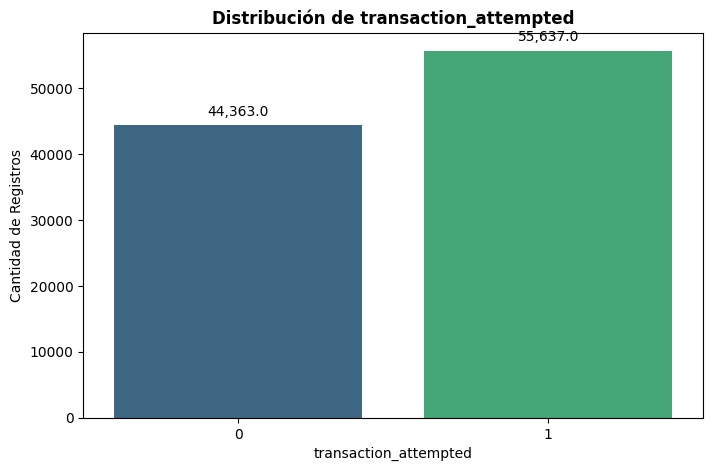

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='transaction_attempted', palette='viridis')
plt.title('Distribución de transaction_attempted', fontweight='bold')
plt.ylabel('Cantidad de Registros')
plt.xlabel('transaction_attempted')

# Agregar etiquetas de datos al gráfico
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

plt.show()